<a href="https://colab.research.google.com/github/qbarger/byu-cs474/blob/master/lab9_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/porterjenkins/byu-cs474/blob/master/lab9_transfer_learning.ipynb)

# Transfer Learning/Fine-Tuning




During training, neural networks often learn features that are useful for a wide variety of tasks. For example, the earliest layers of convolution networks often learn very basic visual features, such as edge detection. These task-agnostic features can be very useful when applied to other tasks. Transfer learning or fine-tuning is a technique that takes a network pretrained on one task and trains it on another. The idea is to tweak or tune the parameters on the new task, rather than making huge changes in learning. Fine-tuning is often quicker than learning on the new task from scratch, and can even lead to better overall performance and generalization.

Unfreezing a pretrained network is a fine-tuning technique that can be helpful when training a network on a difficult task with limited data.
If we allow the network to train its earliest layers immediately, then the earliest layers will forget all of the useful task-agnostic features they learned previously. So, rather than training all of the model weights at once, we learn on the last few layers (which are the most task-specific in the network). We can also gradually start training on the earlier layers as training progresses.

In this lab, you will compare unfreezing fine-tuning techniques against training a model from scratch. You will use the large ResNet-152 model to learn the small Bird Species Classification dataset.



---

## Grading



- 20% Analyze Dataset
- 20% Implementing `BirdNet`
- 20% Implementing `train()`
- 30% Running finetuning experiment
- 10% Answering questions

---

## Lab Setup

In [1]:
import zipfile
import os
import sys
from PIL import Image, ImageOps
import numpy as np
from matplotlib import pyplot as plt
import time
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision import datasets, transforms

In [2]:
device = torch.device("cuda")

---

## Analyze `BirdDataset`



Start by first downloading the dataset from Kaggle.

#### Help for downloading kaggle datasets
Downloading Kaggle datasets requires authentication, so you can't just download from a url. Here are some step-by-step instructions of how to get Kaggle datasets in Colab.

1. Create an API key in Kaggle
    - Click on profile photo
    - Go to 'My Account'
    - Scroll down to the API access section and click "Create New API Token"
    - `kaggle.json` is now downloaded to your computer

2. Upload the API key and install the Kaggle API client by running the next cell (run it again if it throws an error the first time). Also, `files.upload()` may not work in Firefox. One solution is to expand the Files banner (indicated by the '>' tab on the left side of the page) and use that to upload the key.

In [3]:
# Run this cell and select the kaggle.json file downloaded
# from the Kaggle account settings page.
from google.colab import files
files.upload()
# Next, install the Kaggle API client.
!pip install -q kaggle
# Let's make sure the kaggle.json file is present.
!ls -lha kaggle.json
# The Kaggle API client expects this file to be in ~/.kaggle,
# so move it there.
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
# This permissions change avoids a warning on Kaggle tool startup.
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
-rw-r--r-- 1 root root 84 Mar 28 21:26 kaggle.json


3. Copy the desired dataset locally

In [4]:
# Example download command for dataset found here: https://www.kaggle.com/akash2907/bird-species-classification
!kaggle datasets download -d akash2907/bird-species-classification

Dataset URL: https://www.kaggle.com/datasets/akash2907/bird-species-classification
License(s): CC-BY-NC-SA-4.0
100% 1.37G/1.37G [01:37<00:00, 15.2MB/s]



The `BirdDataset` is implemented for you below. Instantiate a `train_dataset` and `val_dataset`.

In [5]:
class BirdDataset(Dataset):
    def __init__(self, zip_file='bird-species-classification.zip', size=256, train=True, upload=False):
        super(BirdDataset, self).__init__()

        self.train = train
        extract_dir = os.path.splitext(zip_file)[0]
        if not os.path.exists(extract_dir):
            os.makedirs(extract_dir)
            self.extract_zip(zip_file, extract_dir)
            # We resize the images - originally they are high resolution. We could do this
            # in the DataLoader, but it will read the full-resolution files from disk
            # every time before resizing them, making training slow
            self.resize(extract_dir, size=size)

        postfix = 'train' if train else 'test'

        if train:
            # The bird-species dataset mistakenly has a train_data folder inside of train_data
            self.dataset_folder = datasets.ImageFolder(os.path.join(extract_dir, 'train_data', 'train_data'), transform=transforms.Compose([transforms.ToTensor()]))
        else:
            self.dataset_folder = datasets.ImageFolder(os.path.join(extract_dir, 'test_data', 'test_data'), transform=transforms.Compose([transforms.ToTensor()]))

    def extract_zip(self, zip_file, extract_dir):
        print("Extracting", zip_file)
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

    def resize(self, path, size=256):
        """Resizes all images in place"""
        print("Resizing images")
        dirs = os.walk(path)
        for root, dirs, files in os.walk(path):
            for item in files:
                name = os.path.join(root, item)
                if os.path.isfile(name):
                    im = Image.open(name)
                    im = ImageOps.fit(im, (size, size))
                    im.save(name[:-3] + 'bmp', 'BMP')
                    os.remove(name)
                else:
                    print(f"else {name}")

    def __getitem__(self, i):
        return self.dataset_folder[i]

    def __len__(self):
        return len(self.dataset_folder)

In [6]:
train_dataset = BirdDataset(train=True)
val_dataset = BirdDataset(train=False)

Extracting bird-species-classification.zip
Resizing images


Print out the number of instances of each class in the `train_dataset` and `val_dataset`.

In [7]:
num_classes = len(train_dataset.dataset_folder.classes)
counts = [0] * num_classes

for _, label in train_dataset:
    counts[label] += 1

class_names = train_dataset.dataset_folder.classes

for i in range(num_classes):
    print(f"{class_names[i]}: {counts[i]}")

blasti: 15
bonegl: 6
brhkyt: 5
cbrtsh: 7
cmnmyn: 7
gretit: 6
hilpig: 10
himbul: 18
himgri: 20
hsparo: 9
indvul: 9
jglowl: 6
lbicrw: 6
mgprob: 6
rebimg: 10
wcrsrt: 10


Print out a single image for each class in a 4x4 display.

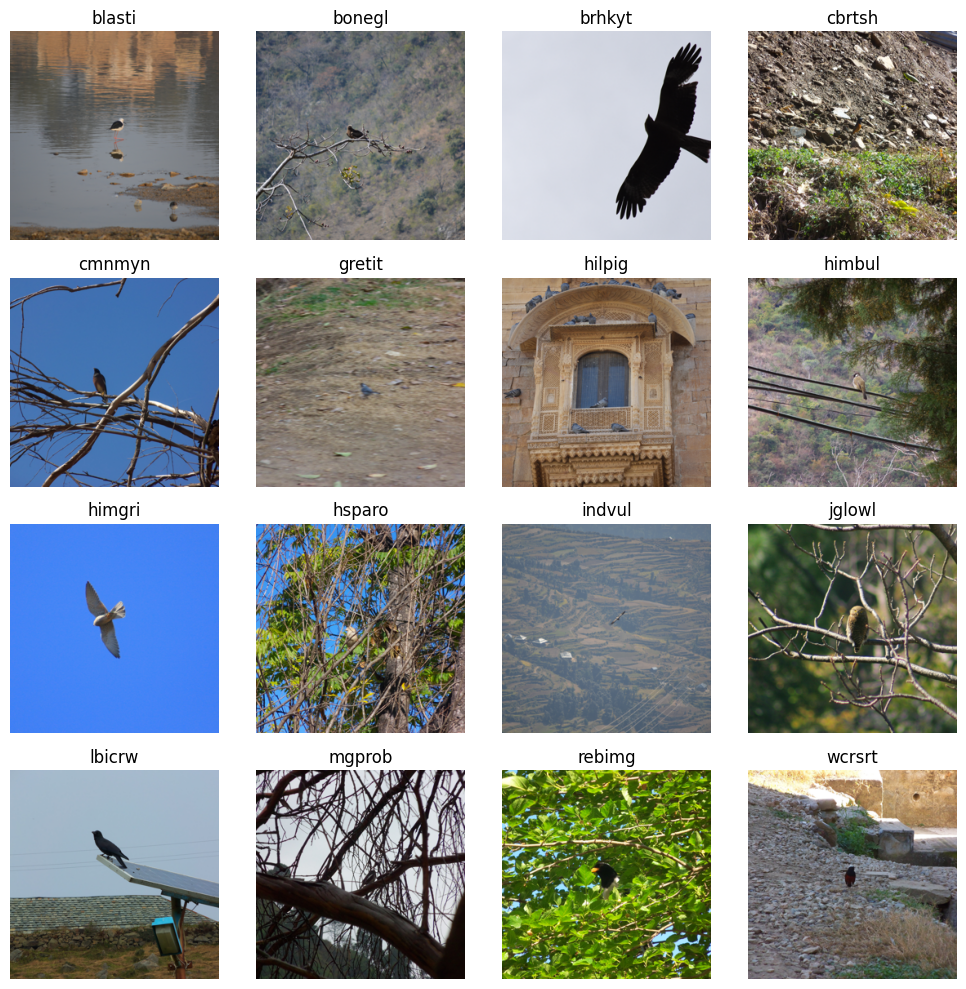

In [12]:
seen = {}
for img, label in train_dataset:
    if label not in seen:
        seen[label] = img
    if len(seen) == len(class_names):
        break

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, (label, img) in enumerate(seen.items()):
    ax = axes[i // 4, i % 4]

    # convert tensor
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

You will notice that not only do we have a small training dataset (150 images), some of the images are potentially difficult to classify because of how small the bird appears in the image. If you investigated the images further you would notice that many images of a given class are subsequent snapshots of the same bird. This will make generalization hard and overfitting easy, especially with a large network.

---

## Implement `BirdNet`





Implement the `BirdNet`: a wrapper class adding functionality to a (pretrained) `ResNet`.


### Implement `__init__()`

- The `BirdNet` should first instantiate a `models.resnet152` object and optionally, load in pretrained weights (look at https://pytorch.org/vision/stable/models.html for more information about using pretrained weights). We suggest using `models.ResNet152_Weights.IMAGENET1K_V1`.
- Overwrite the final layer in the ResNet to linearly map (with `nn.Linear`) the previous layers features to `n_classes`.
- Freeze all weights except the final layer. You can do this with calling `.requires_grad = False` on the parameters or calling `.requires_grad(False)` on the layers.


### Implement `unfreeze()`


Implement `unfreeze()` to unfreeze the last `n_layers` of your model. Do not treat the sequential or bottleneck layers in the ResNet as a single layer; we consider a convolutional layer or linear layer as a single layer. You may optionally treat a batchnorm layer as its own layer or as part of a conv/linear layer. ReLU layers do not have parameters, so they can't be frozen/unfrozen.

**Tip**: *You can print out a `models.resnet152` object to get an idea of how many input features are used in the last layer as well as the structure and naming convention used by the ResNet to know how to unfreeze `n_layers`.*

Create a temporary resnet152 model and print it here to see the structure of the network and the naming conventions. You can iterate over `.named_parameters()` to get the name and parameter object, respectively, to verify the naming scheme. This function can make your unfreezing function simpler.

In [13]:
class BirdNet(nn.Module):
    def __init__(self, n_classes, pretrained_weights):
        super().__init__()

        if pretrained_weights:
          weights = models.ResNet152_Weights.IMAGENET1K_V1
          self.net = models.resnet152(weights=weights)
        else:
          self.net = models.resnet152(weights=None)

        # freeze weights
        if pretrained_weights:
          for param in self.net.parameters():
              param.requires_grad = False

        # overwrite final layer
        in_features = self.net.fc.in_features
        self.net.fc = nn.Linear(in_features, n_classes)

        # unfreeze final layer
        for param in self.net.fc.parameters():
          param.requires_grad = True

    def unfreeze(self, n_layers):
        params = list(self.net.named_parameters())

        # work backwards and unfreeze last n layers
        count = 0
        for name, param in reversed(params):
            if not param.requires_grad:
                param.requires_grad = True
                count += 1

            if count >= n_layers:
                break

    def forward(self, x):
        return self.net(x)

---

## Training

In [14]:
@torch.no_grad()
def accuracy(y_hat, y_truth):
    preds = torch.argmax(y_hat, dim=1)
    acc = torch.mean((preds == y_truth).float())
    return acc.item()


@torch.no_grad()
def evaluate(model, loss_fn, val_loader):
    val_losses = 0
    val_accs = 0
    # model.eval() so that batchnorm and dropout work in eval mode
    model.eval()

    for x, y_truth in val_loader:
        x, y_truth = x.to(device), y_truth.to(device)
        y_hat = model(x)
        val_losses += loss_fn(y_hat, y_truth).item() * len(x)
        val_accs += accuracy(y_hat, y_truth) * len(x)

    model.train()
    return val_losses/len(val_dataset), val_accs/len(val_dataset)


Implement the `train()` function. Keep track of the usual performance metrics (training/validation losses and accuracies) and additionally keep track of how long, in seconds, training took (this is referred to as wallclock training time).

There are two additional arguments in `train()`: `slowly_unfreeze` and `unfreeze_interval`.
 If `slowly_unfreeze=True` then for every `unfreeze_interval` number of steps you should unfreeze an additional layer from your model.

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

loss_fn = nn.CrossEntropyLoss()

def train(model, optimizer, n_optimization_steps, log_interval, slowly_unfreeze, unfreeze_interval):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    step = 0
    start_time = time.time()

    model.train()

    while step < n_optimization_steps:
      for x, y_truth in train_loader:
          if step >= n_optimization_steps:
              break

          x, y_truth = x.to(device), y_truth.to(device)

          # forward
          y_hat = model(x)
          loss = loss_fn(y_hat, y_truth)

          # backward
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          # accuracy and losses
          acc = accuracy(y_hat, y_truth)

          train_losses.append(loss.item())
          train_accs.append(acc)

          # gradual unfreezing
          if slowly_unfreeze and step % unfreeze_interval == 0 and step > 0:
              model.unfreeze(1)

          # logging + evaluate
          if step % log_interval == 0:
              val_loss, val_acc = evaluate(model, loss_fn, val_loader)

              val_losses.append(val_loss)
              val_accs.append(val_acc)

              print(f"Step {step}: "
                    f"Train Loss={loss.item():.4f}, Train Acc={acc:.4f}, "
                    f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

          step += 1

    total_time = time.time() - start_time

    return {
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "training_time_sec": total_time
    }

To compare how well finetuning works you will perform a set of experiments. There are four models you will train for `n_trials >= 3`:
- `res-reinit`: A reinitialized (not pretrained) resnet model. This is the baseline.
- `res1`: A pretrained resnet model with only the last layer unfrozen.
- `res3`: A pretrained resnet model with the last 3 layers unfrozen.
- `res10-slow`: A pretrained resnet model with the last 10 layers **slowly** unfrozen.

For each model average the results across the `n_trials` and plot the val accuracy across time for each model and print out the average wallclock time and time per optimization step (i.e. wallclock_time / optimization_step) . **Do not forget to recreate the model and optimizer between each trial.**


**Tip:** Make sure everything is implemented correctly before running all `n_trials` on all four models. We found that a learning rate of .001 worked well for 100 optimization steps.

In [20]:
def train_trials(n_trials, model_kwargs):
    all_train_losses = []
    all_train_accs = []
    all_val_losses = []
    all_val_accs = []
    all_times = []

    for n in range(n_trials):
        # TODO: instantiate a model using model_kwargs
        model = BirdNet(
            n_classes=len(train_dataset.dataset_folder.classes),
            pretrained_weights=model_kwargs["pretrained_weights"]
        ).to(device)

        if model_kwargs.get("initial_unfreeze", 0) > 0:
            model.unfreeze(model_kwargs["initial_unfreeze"])

        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3
        )

        # train the model
        results = train(
            model,
            optimizer,
            n_optimization_steps=100,
            log_interval=10,
            slowly_unfreeze=model_kwargs.get("slowly_unfreeze", False),
            unfreeze_interval=model_kwargs.get("unfreeze_interval", 10)
        )

        # TODO: Store train & val loss, accuracies, and total wallclock time
        all_train_losses.append(results["train_losses"])
        all_train_accs.append(results["train_accs"])
        all_val_losses.append(results["val_losses"])
        all_val_accs.append(results["val_accs"])
        all_times.append(results["training_time_sec"])

    # convert to np for mean function
    avg_train_losses = np.mean(all_train_losses, axis=0)
    avg_train_accs = np.mean(all_train_accs, axis=0)
    avg_val_losses = np.mean(all_val_losses, axis=0)
    avg_val_accs = np.mean(all_val_accs, axis=0)
    avg_time = np.mean(all_times)
    time_per_step = avg_time / 100

    print(f"\nAvg wallclock time: {avg_time:.2f}s")
    print(f"Time per step: {time_per_step:.4f}s")

    return {
        "train_losses": avg_train_losses,
        "train_accs": avg_train_accs,
        "val_losses": avg_val_losses,
        "val_accs": avg_val_accs,
        "avg_time": avg_time,
        "time_per_step": time_per_step
    }

Step 0: Train Loss=2.9239, Train Acc=0.0000, Val Loss=30.0914, Val Acc=0.1210
Step 10: Train Loss=2.3317, Train Acc=0.3125, Val Loss=3.2072, Val Acc=0.0955
Step 20: Train Loss=2.0951, Train Acc=0.2188, Val Loss=3.8612, Val Acc=0.0573
Step 30: Train Loss=1.7714, Train Acc=0.3125, Val Loss=4.3818, Val Acc=0.1274
Step 40: Train Loss=1.8884, Train Acc=0.3125, Val Loss=3.5484, Val Acc=0.1656
Step 50: Train Loss=1.7938, Train Acc=0.4375, Val Loss=3.5620, Val Acc=0.1975
Step 60: Train Loss=1.2836, Train Acc=0.5000, Val Loss=2.9929, Val Acc=0.2293
Step 70: Train Loss=1.5013, Train Acc=0.5312, Val Loss=3.4671, Val Acc=0.3121
Step 80: Train Loss=1.6133, Train Acc=0.4688, Val Loss=4.4471, Val Acc=0.2739
Step 90: Train Loss=1.1996, Train Acc=0.4688, Val Loss=3.3958, Val Acc=0.1656
Step 0: Train Loss=3.0595, Train Acc=0.1562, Val Loss=57.2885, Val Acc=0.0701
Step 10: Train Loss=2.8328, Train Acc=0.2188, Val Loss=3.6596, Val Acc=0.0382
Step 20: Train Loss=2.1408, Train Acc=0.3438, Val Loss=4.0824, V

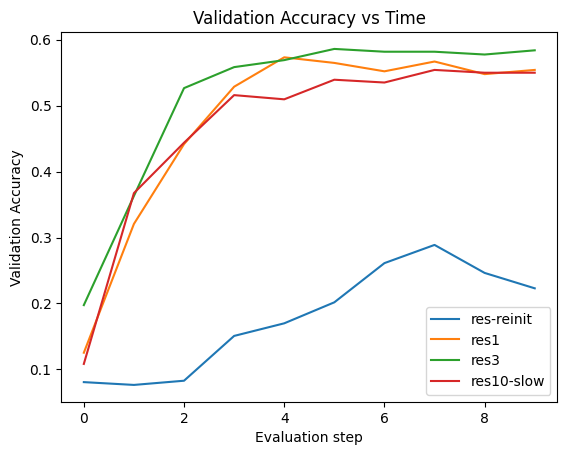

In [21]:
# Run trials for all models

# set models
res_reinit = {
    "pretrained_weights": False,
    "initial_unfreeze": 0,
    "slowly_unfreeze": False
}

res1 = {
    "pretrained_weights": True,
    "initial_unfreeze": 0,
    "slowly_unfreeze": False
}

res3 = {
    "pretrained_weights": True,
    "initial_unfreeze": 3,
    "slowly_unfreeze": False
}

res10_slow = {
    "pretrained_weights": True,
    "initial_unfreeze": 0,
    "slowly_unfreeze": True,
    "unfreeze_interval": 10
}

# run trials
n_trials = 3

results_reinit = train_trials(n_trials, res_reinit)
results_res1 = train_trials(n_trials, res1)
results_res3 = train_trials(n_trials, res3)
results_res10_slow = train_trials(n_trials, res10_slow)

# plot model outcomes
plt.plot(results_reinit["val_accs"], label="res-reinit")
plt.plot(results_res1["val_accs"], label="res1")
plt.plot(results_res3["val_accs"], label="res3")
plt.plot(results_res10_slow["val_accs"], label="res10-slow")

plt.xlabel("Evaluation step")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Validation Accuracy vs Time")
plt.show()

---

## Questions



- Which model performed the best?
- How do the finetuned models compare to the reinitialized model in terms of time?
- Why are the ImageNet weights helpful to learning the Bird dataset?
- Why do we only unfreeze the last few layers?
- What are some pros and cons of pretraining?

The model that performed the best was the res3, followed closely by the res1, res10-slow, and distantly by the res-reinit. The finetuned models are much faster than the reinitialized model in terms of time. In fact, they are about 2 times faster than the res-reinit model. This is because they are able to leverage the ImageNet, which has been optimized for image classification.

The ImageNet weights are helpful for learning the Bird dataset because it has already been trained on a much larger dataset and the weights have been adjusted to effectively identify more general features. Without the ImageNet, the BirdNet would probably overfit to the small Bird dataset. When we wrap the ImageNet with BirdNet we can utilize ImageNet's previous "knowledge" and then focus the last layers on learning the bird characteristics.

We only freeze the last few layers because it allows us to better leverage ImageNet. We don't want to disrupt ImageNet's weights, so we only unfreeze the last few layers so BirdNet can adjust based on the more specific bird features (since early layers learn more general features and deeper layers learn more specific features). I'm surprised the res3 and res1 were better than the res10-slow, since the res10-slow should gradually adjust to more bird features. It seems like it had a better trajectory and then flatlined a little bit.

Pretraining can be effective in cases like this where there is a small dataset we are trying to learn. It allows us to use good general knowledge, and then finetune that knowledge for a specific case like birds. It is also much faster as we can see from the graph. I imagine if there was a much bigger dataset it would probably be more effective to train only on that dataset rather than pretrain. When you pretrain you also have to make sure that you choose a good pretrained model because your wrapper model is at the mercy of whatever the pretrained model's knowledge is.